In [59]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

# SKA
## With Galactic Noise

In [60]:
c_60 = np.load("results/60K_1000samples_size800/Cov.npy")
c_200 = np.load("results/200K_1000samples_size800/Cov.npy")
c_300 = np.load("results/300K_1000samples_size800/Cov.npy")

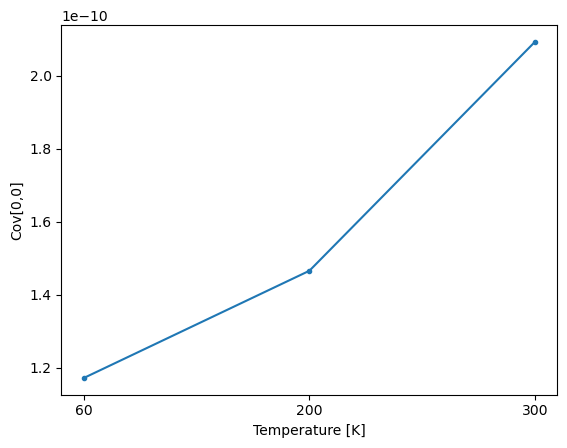

In [61]:
plt.plot(np.arange(3), [c_60[0,0], c_200[0,0], c_300[0,0]], marker=".")
plt.xlabel("Temperature [K]")
plt.xticks(np.arange(3), [60, 200, 300])
plt.ylabel(r"Cov[0,0]")
plt.show()

In [62]:
def transform_cov_for_1D(cov, display_bin):
    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    return small_cov/np.max(small_cov, axis=1)[:, None]

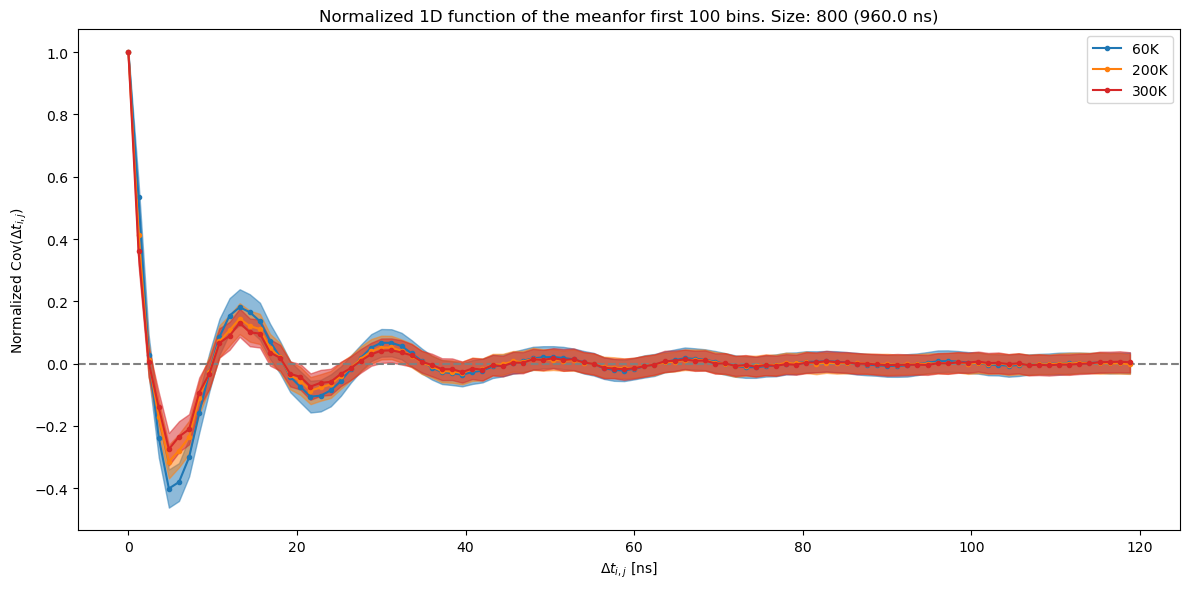

In [63]:
display_bin = 100
dur = c_60.shape[0]

s_60 = transform_cov_for_1D(c_60, display_bin)
mean_60 = np.mean(s_60, axis=0)
stds_60 = np.std(s_60, axis=0)

s_200 = transform_cov_for_1D(c_200, display_bin)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

s_300 = transform_cov_for_1D(c_300, display_bin)
mean_300 = np.mean(s_300, axis=0)
stds_300 = np.std(s_300, axis=0)

small_x = np.arange(display_bin)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_60-stds_60, mean_60+stds_60, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)
plt.fill_between(small_x, mean_300-stds_300, mean_300+stds_300, color="tab:red", alpha=0.5)

# plt.plot(small_x, s_60[0], c="tab:blue", marker=".", label="60K")
# plt.plot(small_x, s_200[0], c="tab:orange", marker=".", label="200K")
# plt.plot(small_x, s_300[0], c="tab:red", marker=".", label="300K")

plt.plot(small_x, mean_60, c="tab:blue", marker=".", label="60K")
plt.plot(small_x, mean_200, c="tab:orange", marker=".", label="200K")
plt.plot(small_x, mean_300, c="tab:red", marker=".", label="300K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

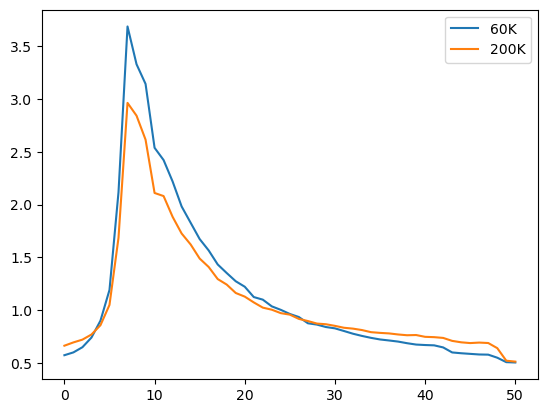

In [64]:
fourier = np.fft.rfft(mean_60)
plt.plot(np.abs(fourier), label="60K")
fourier = np.fft.rfft(mean_200)
plt.plot(np.abs(fourier), label="200K")
plt.legend()
plt.show()

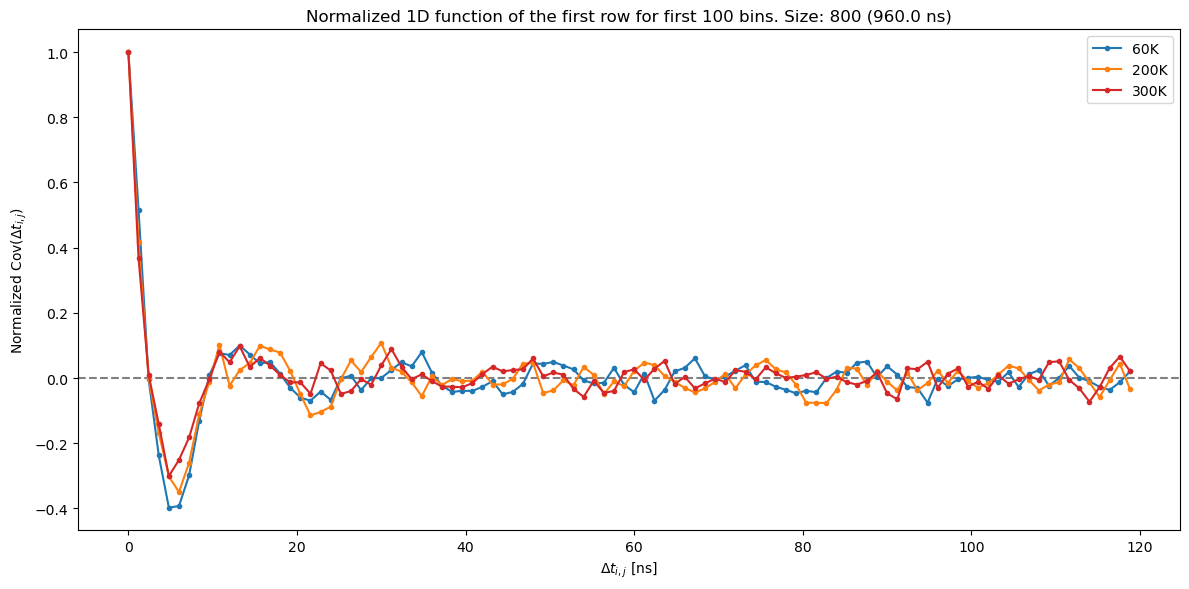

In [65]:
display_bin = 100
dur = c_60.shape[0]

s_60 = transform_cov_for_1D(c_60, display_bin)
mean_60 = np.mean(s_60, axis=0)
stds_60 = np.std(s_60, axis=0)

s_200 = transform_cov_for_1D(c_200, display_bin)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

s_300 = transform_cov_for_1D(c_300, display_bin)
mean_300 = np.mean(s_300, axis=0)
stds_300 = np.std(s_300, axis=0)

small_x = np.arange(display_bin)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

# plt.fill_between(small_x, mean_60-stds_60, mean_60+stds_60, color="tab:blue", alpha=0.5)
# plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)
# plt.fill_between(small_x, mean_300-stds_300, mean_300+stds_300, color="tab:red", alpha=0.5)

plt.plot(small_x, s_60[0], c="tab:blue", marker=".", label="60K")
plt.plot(small_x, s_200[0], c="tab:orange", marker=".", label="200K")
plt.plot(small_x, s_300[0], c="tab:red", marker=".", label="300K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

## Without Galactic Noise

In [66]:
c_60_ng = np.load("results/NoGal_60K_1000samples_size800/Cov.npy")
c_200_ng = np.load("results/NoGal_200K_1000samples_size800/Cov.npy")
# c_300_ng = np.load("results/NoGal_300K_1000samples_size800/Cov.npy")

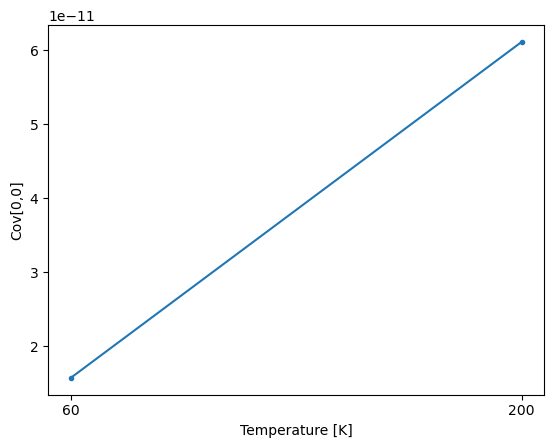

In [67]:
plt.plot(np.arange(2), [c_60_ng[0,0], c_200_ng[0,0]], marker=".")
plt.xlabel("Temperature [K]")
plt.xticks(np.arange(2), [60, 200])
plt.ylabel(r"Cov[0,0]")
plt.show()

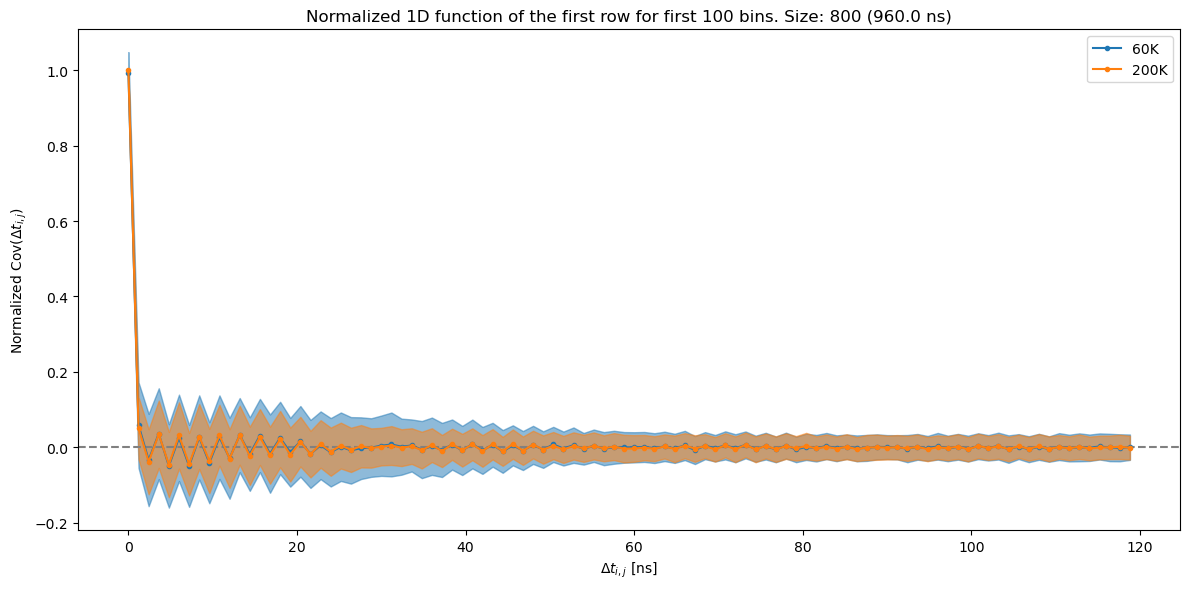

In [68]:
display_bin = 100
dur = c_60.shape[0]

s_60_ng = transform_cov_for_1D(c_60_ng, display_bin)
mean_60_ng = np.mean(s_60_ng, axis=0)
stds_60_ng = np.std(s_60_ng, axis=0)

s_200_ng = transform_cov_for_1D(c_200_ng, display_bin)
mean_200_ng = np.mean(s_200_ng, axis=0)
stds_200_ng = np.std(s_200_ng, axis=0)

small_x = np.arange(display_bin)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_60_ng-stds_60_ng, mean_60_ng+stds_60_ng, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_200_ng-stds_200_ng, mean_200_ng+stds_200_ng, color="tab:orange", alpha=0.5)

plt.plot(small_x, mean_60_ng, c="tab:blue", marker=".", label="60K")
plt.plot(small_x, mean_200_ng, c="tab:orange", marker=".", label="200K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

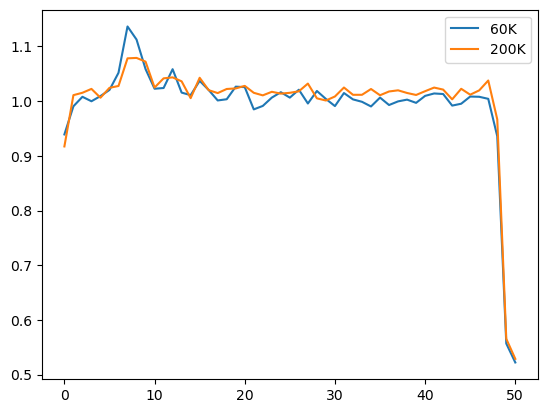

In [69]:
fourier = np.fft.rfft(mean_60_ng)
plt.plot(np.abs(fourier), label="60K")
fourier = np.fft.rfft(mean_200_ng)
plt.plot(np.abs(fourier), label="200K")
plt.legend()
plt.show()

So, really the galactic noise is the cause of correlation, as w/o galactic noise is much more diagonal = fourier is flat. 

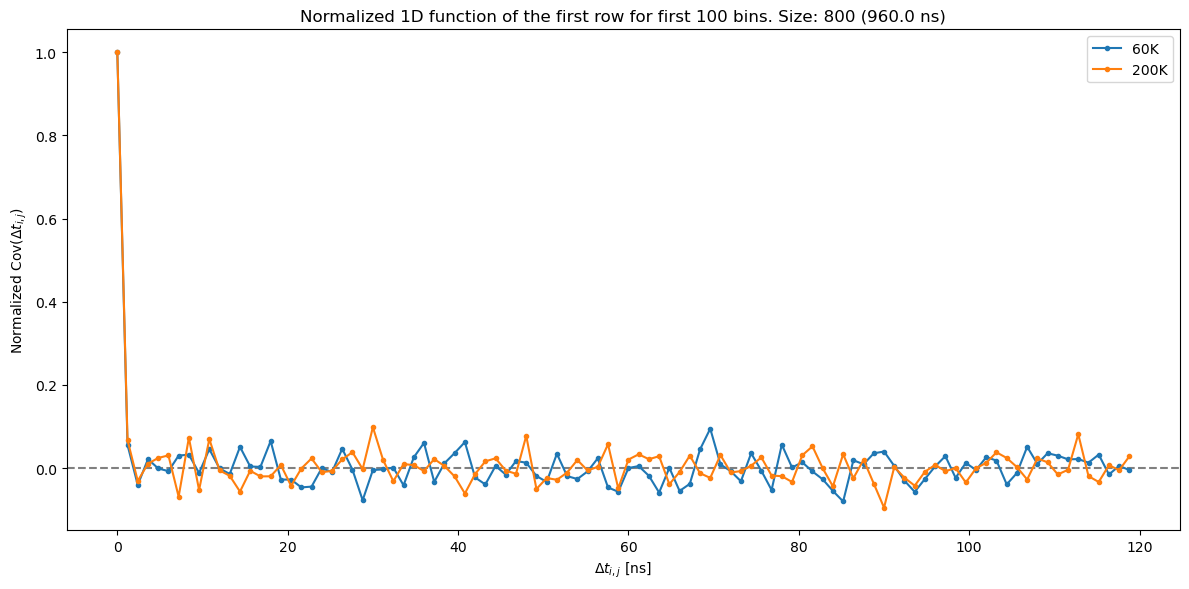

In [70]:
plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

# plt.fill_between(small_x, mean_60-stds_60, mean_60+stds_60, color="tab:blue", alpha=0.5)
# plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)
# plt.fill_between(small_x, mean_300-stds_300, mean_300+stds_300, color="tab:red", alpha=0.5)

plt.plot(small_x, s_60_ng[0], c="tab:blue", marker=".", label="60K")
plt.plot(small_x, s_200_ng[0], c="tab:orange", marker=".", label="200K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

## With/without Galactice Noise

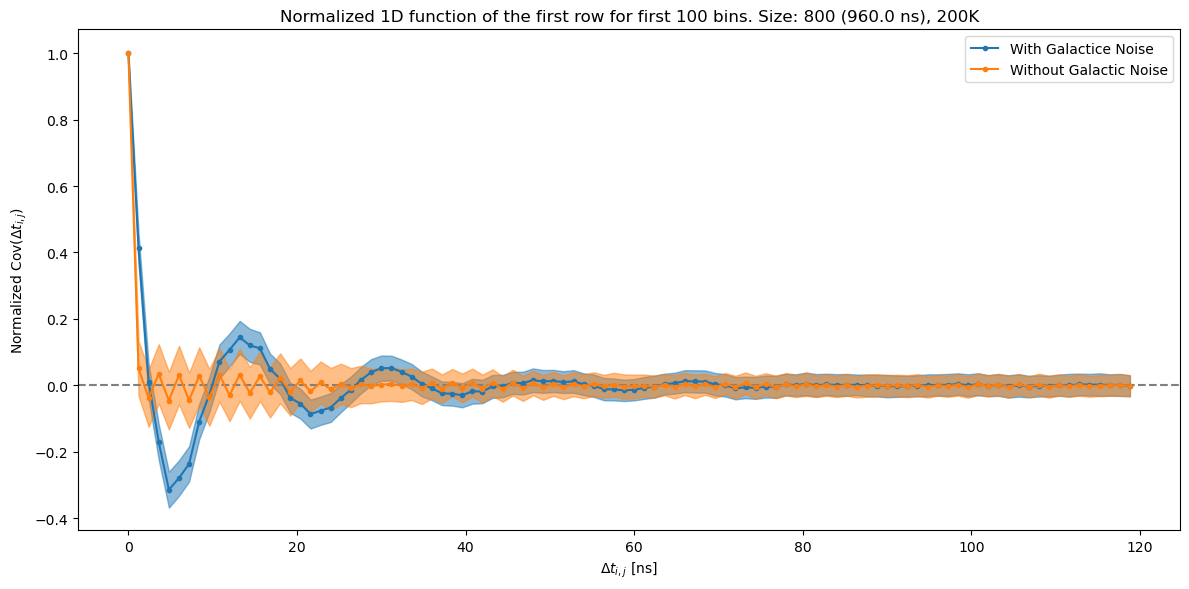

In [71]:
plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_200_ng-stds_200_ng, mean_200_ng+stds_200_ng, color="tab:orange", alpha=0.5)

plt.plot(small_x, mean_200, c="tab:blue", marker=".", label="With Galactice Noise")
plt.plot(small_x, mean_200_ng, c="tab:orange", marker=".", label="Without Galactic Noise")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns), 200K")
plt.tight_layout()

plt.show()

# LOFAR
## Compare across stations vs single station

In [72]:
single_trace = np.load("/home/rkitahara/Research/Cov/SKA_Cov/results/LOFAR_200K_1000samples_size200/traces.npy")

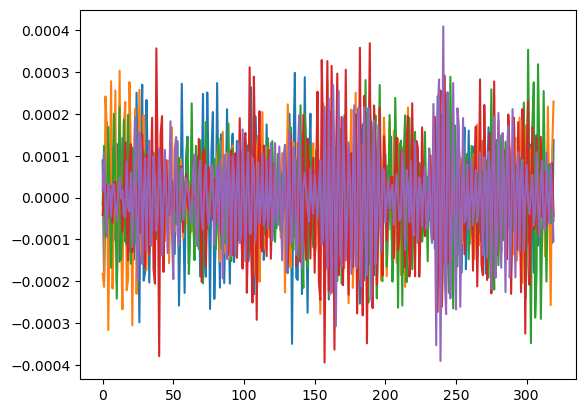

In [73]:
for i in range(5):
    plt.plot(single_trace[i])
plt.show()

In [74]:
single = np.load("/home/rkitahara/Research/Cov/SKA_Cov/results/LOFAR_200K_1000samples_size200/Cov.npy")
mult = np.load("/home/rkitahara/Research/Cov/SKA_Cov/results/LOFAR_200K_1000samples_size200_acrosschan/Cov.npy")

In [75]:
def transform_cov_for_1D(cov, display_bin):
    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    return small_cov
    # return small_cov/np.max(small_cov, axis=1)[:, None]

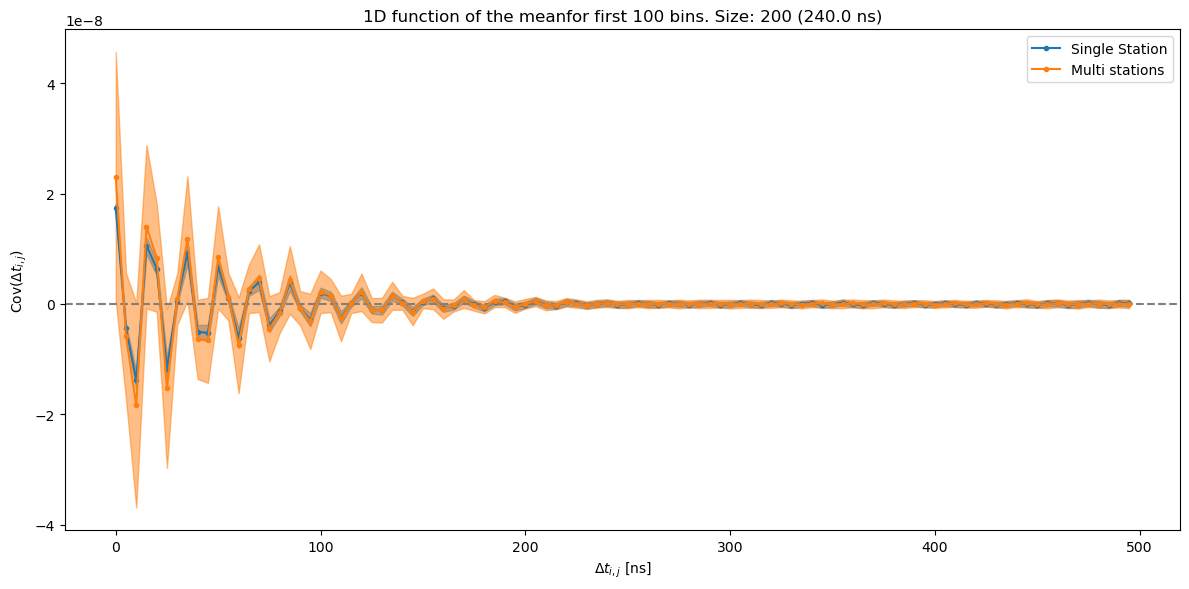

In [76]:
display_bin = 100
dur = single.shape[0]

s_single = transform_cov_for_1D(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_mult = transform_cov_for_1D(mult, display_bin)
mean_mult = np.mean(s_mult, axis=0)
stds_mult = np.std(s_mult, axis=0)

small_x = np.arange(display_bin)*5

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_mult-stds_mult, mean_mult+stds_mult, color="tab:orange", alpha=0.5)

plt.plot(small_x, mean_single, c="tab:blue", marker=".", label="Single Station")
plt.plot(small_x, mean_mult, c="tab:orange", marker=".", label="Multi stations")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Cov($\Delta t_{i,j}$)")

plt.title(f"1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()


## Compare with Measured
### With General Gaussian Model

In [77]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [78]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

meas = cov(single.shape[0], A, omega0, gamma, p, C)

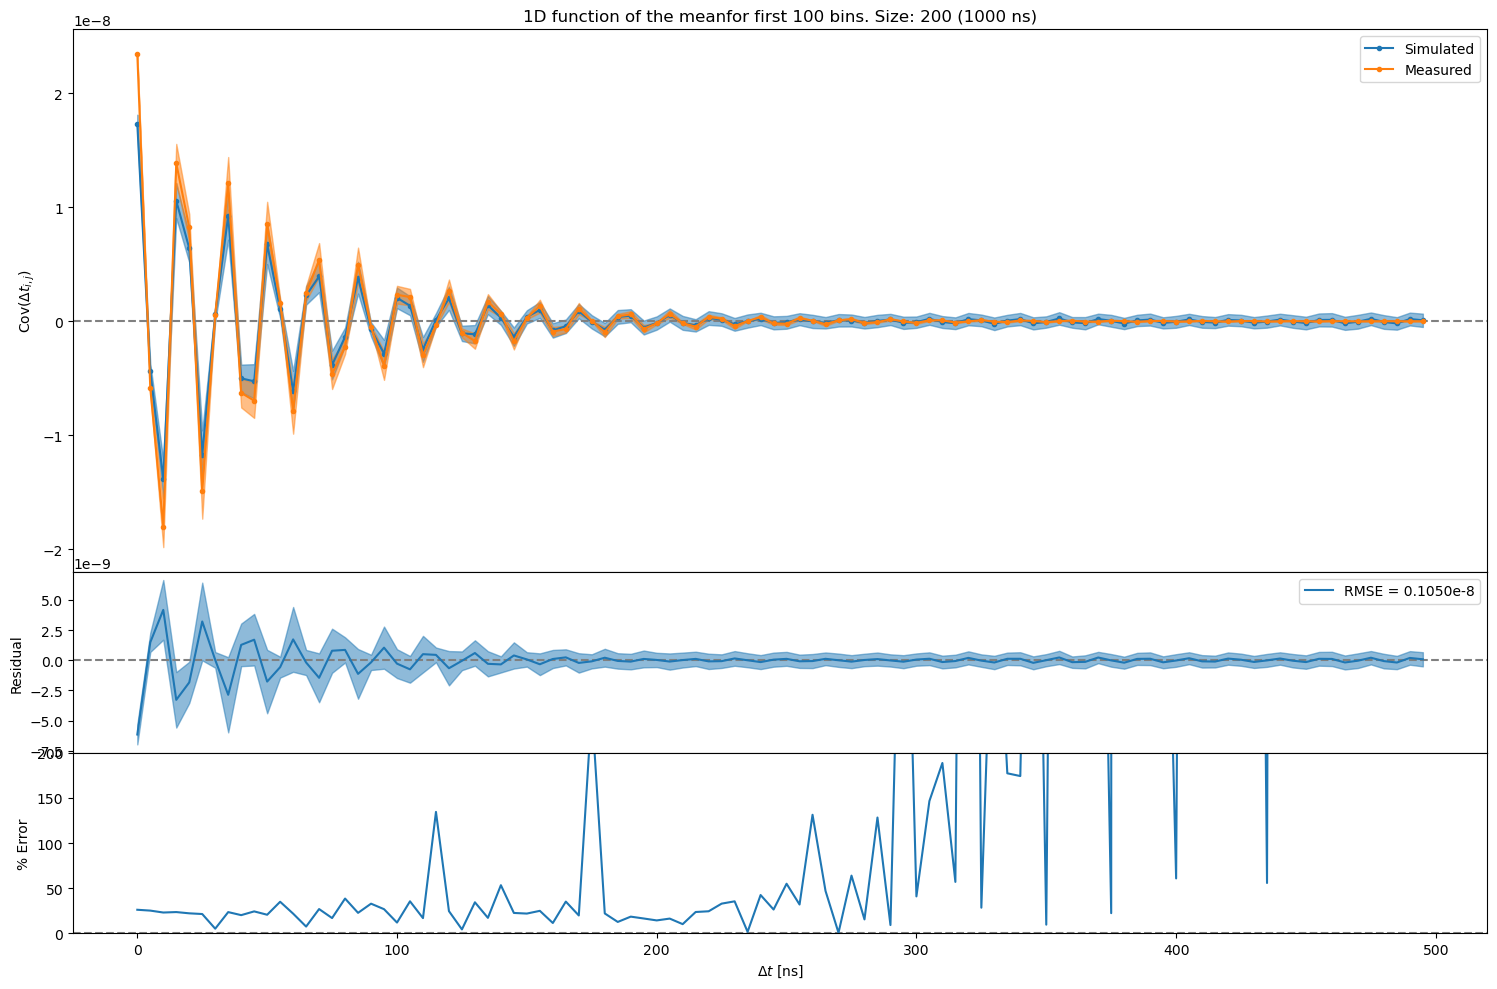

In [104]:
display_bin = 100
dur = single.shape[0]

s_single = transform_cov_for_1D(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas = transform_cov_for_1D(meas, display_bin)
mean_meas = np.mean(s_meas, axis=0)
stds_meas = np.std(s_meas, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas-stds_meas, mean_meas+stds_meas, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas
diff_err = np.sqrt(stds_meas**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))*1e+8
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}e-8")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 200)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()


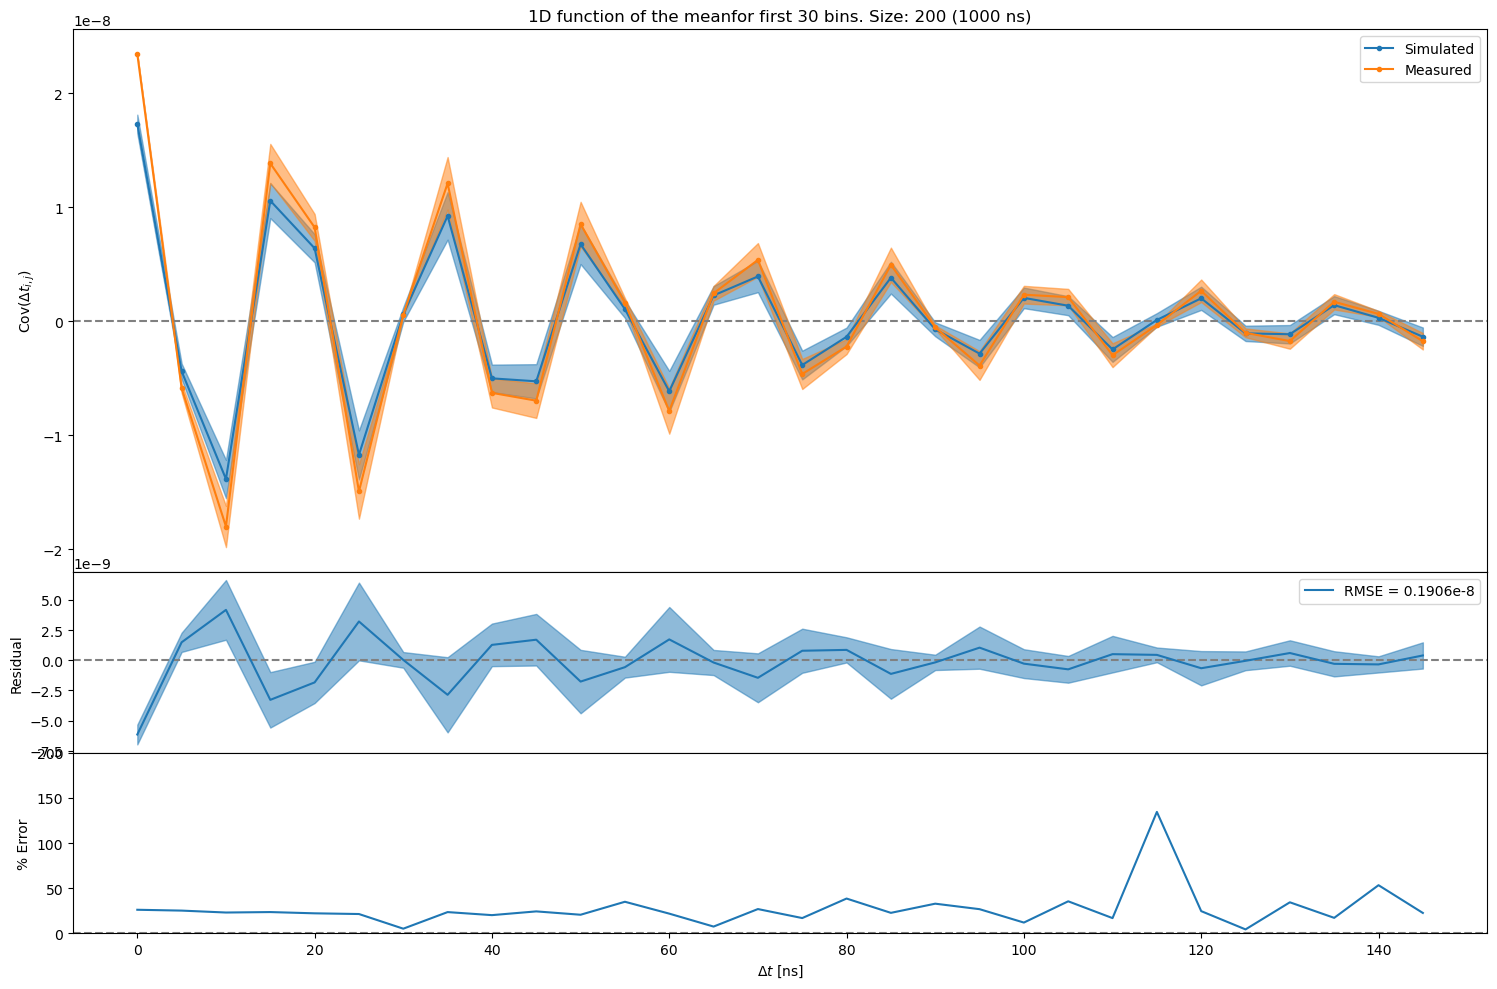

In [ ]:
display_bin = 30
dur = single.shape[0]

s_single = transform_cov_for_1D(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas = transform_cov_for_1D(meas, display_bin)
mean_meas = np.mean(s_meas, axis=0)
stds_meas = np.std(s_meas, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas-stds_meas, mean_meas+stds_meas, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas
diff_err = np.sqrt(stds_meas**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))*1e+8
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}e-8")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 200)
for i in range(len(per_err)):
    axes[2].text()

plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()

In [87]:
def transform_cov_for_1D_norm(cov, display_bin):
    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    return small_cov/np.max(small_cov, axis=1)[:, None]

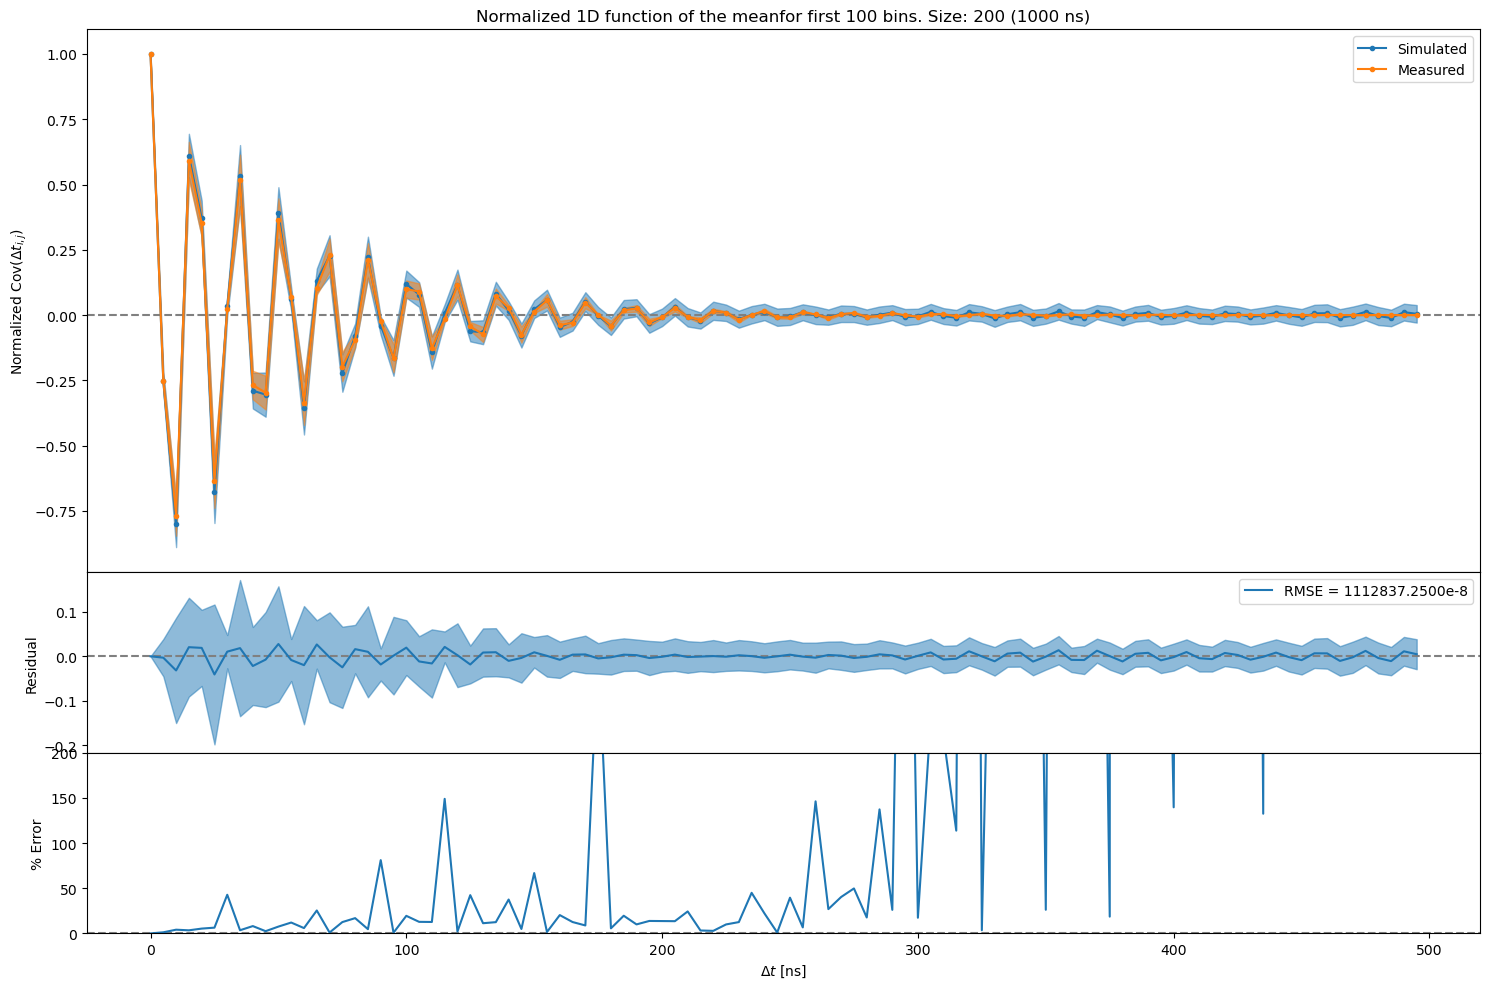

In [124]:
display_bin = 100
dur = single.shape[0]

s_single = transform_cov_for_1D_norm(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas = transform_cov_for_1D_norm(meas, display_bin)
mean_meas = np.mean(s_meas, axis=0)
stds_meas = np.std(s_meas, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas-stds_meas, mean_meas+stds_meas, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"Normalized 1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas
diff_err = np.sqrt(stds_meas**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))*1e+8
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}e-8")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 200)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()


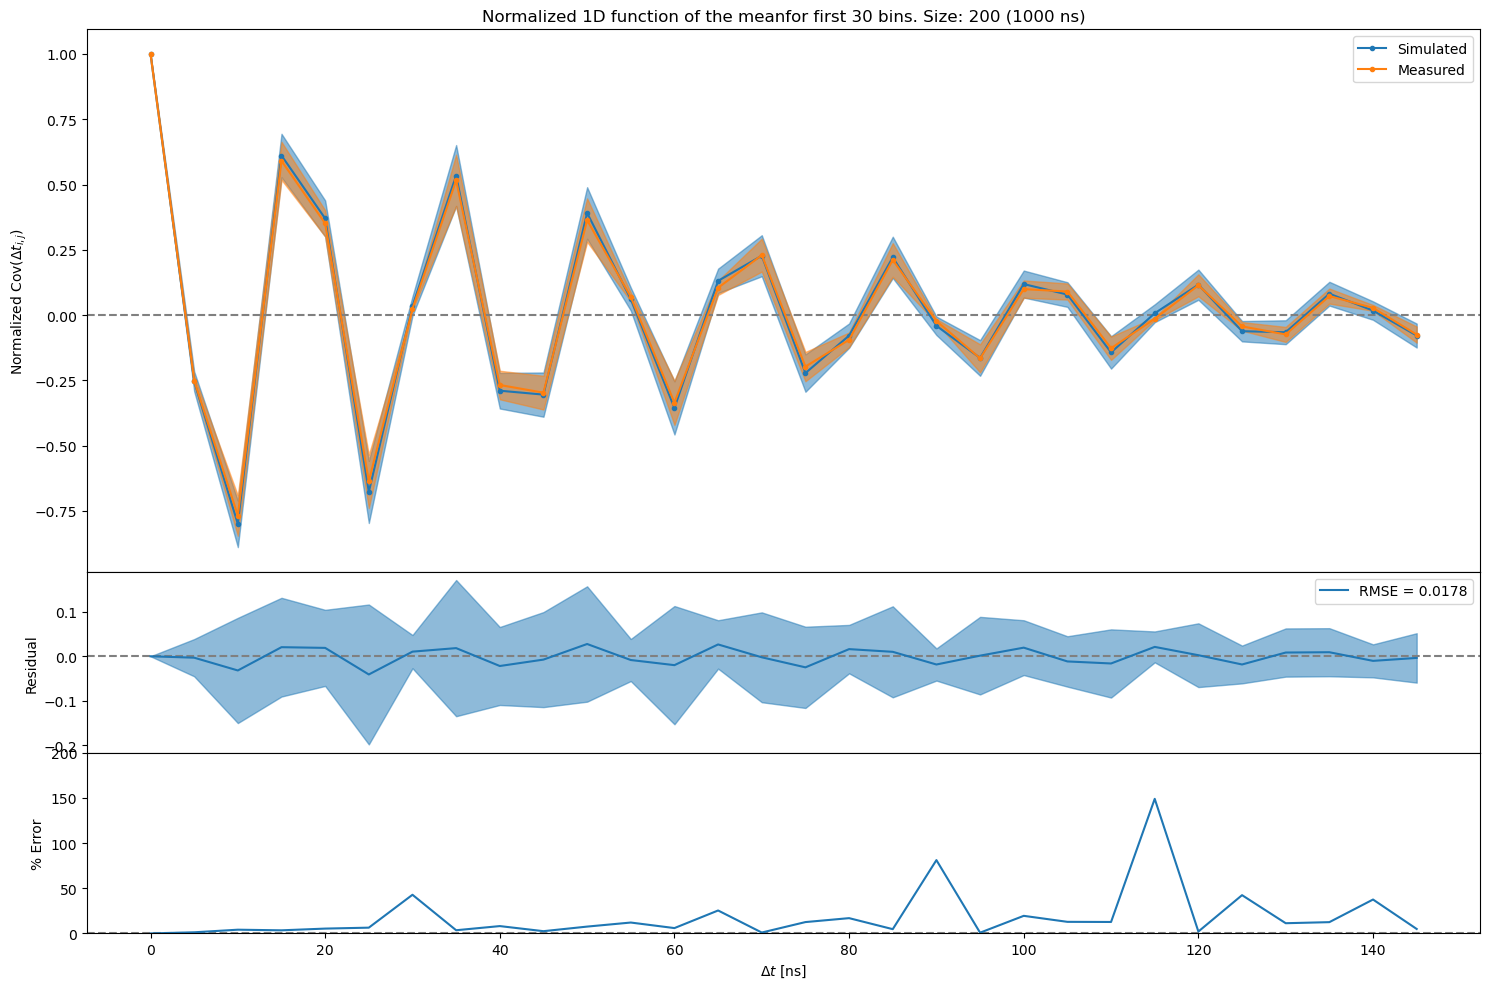

In [125]:
display_bin = 30
dur = single.shape[0]

s_single = transform_cov_for_1D_norm(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas = transform_cov_for_1D_norm(meas, display_bin)
mean_meas = np.mean(s_meas, axis=0)
stds_meas = np.std(s_meas, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas-stds_meas, mean_meas+stds_meas, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"Normalized 1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas
diff_err = np.sqrt(stds_meas**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 200)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()


### With Actual Data

In [109]:
meas_data = np.load("/home/rkitahara/Research/Cov/time_dependence/results/Covs/event_93970574_200/Cov.npy")

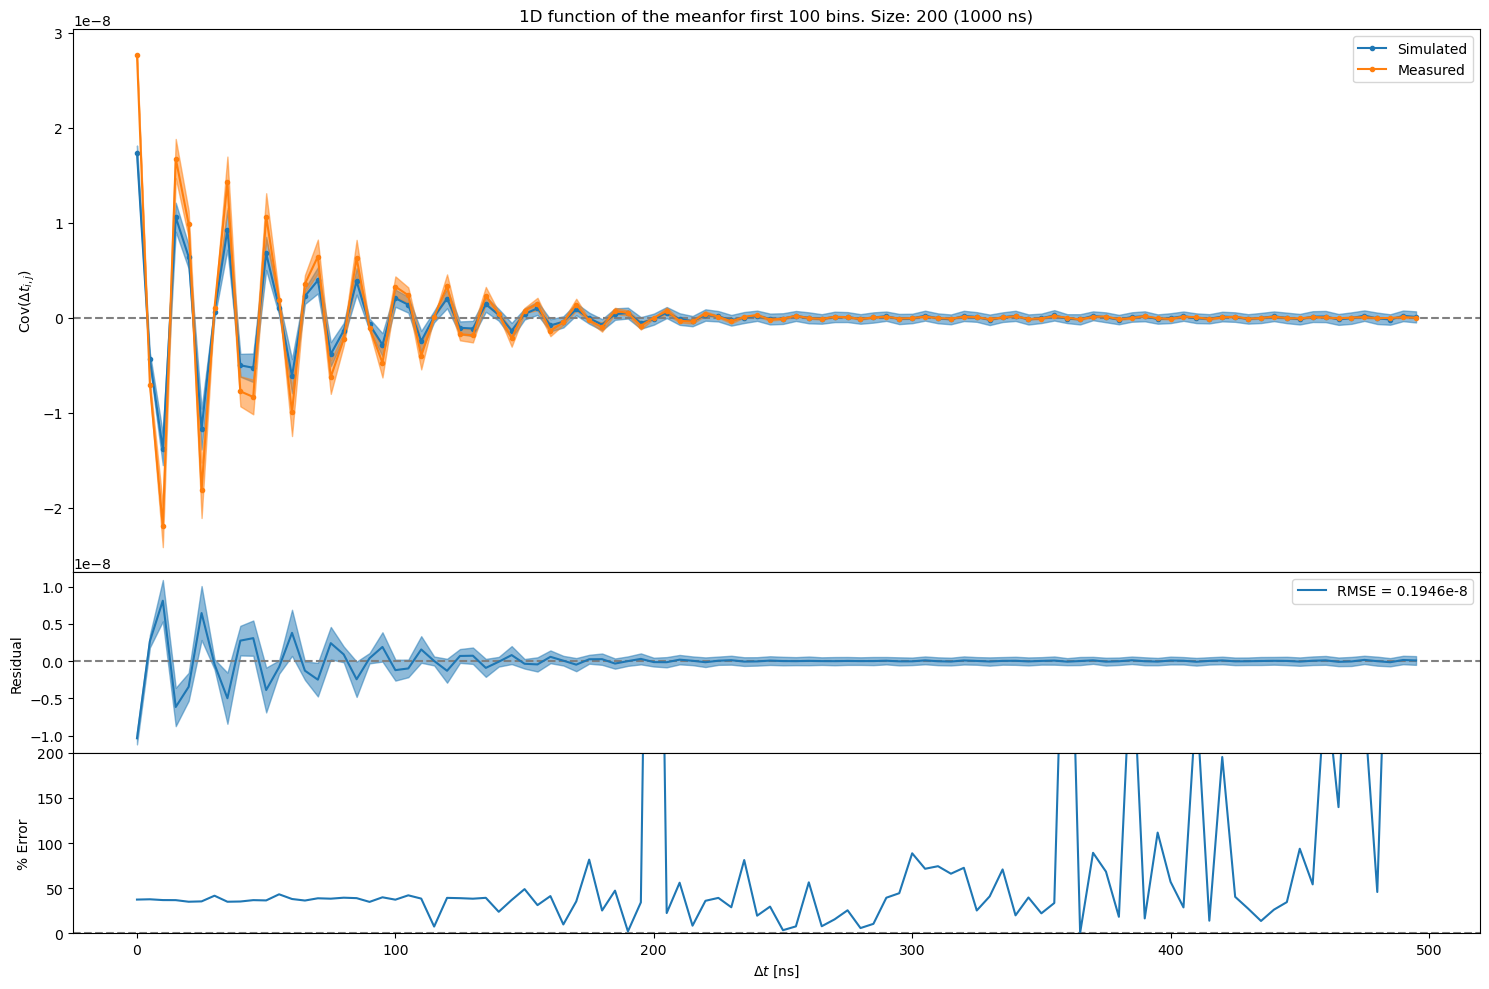

In [117]:
display_bin = 100
dur = single.shape[0]

s_single = transform_cov_for_1D(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas_data = transform_cov_for_1D(meas_data, display_bin)
mean_meas_data = np.mean(s_meas_data, axis=0)
stds_meas_data = np.std(s_meas_data, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas_data-stds_meas_data, mean_meas_data+stds_meas_data, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas_data, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas_data
diff_err = np.sqrt(stds_meas_data**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))*1e+8
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}e-8")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas_data *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 200)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()


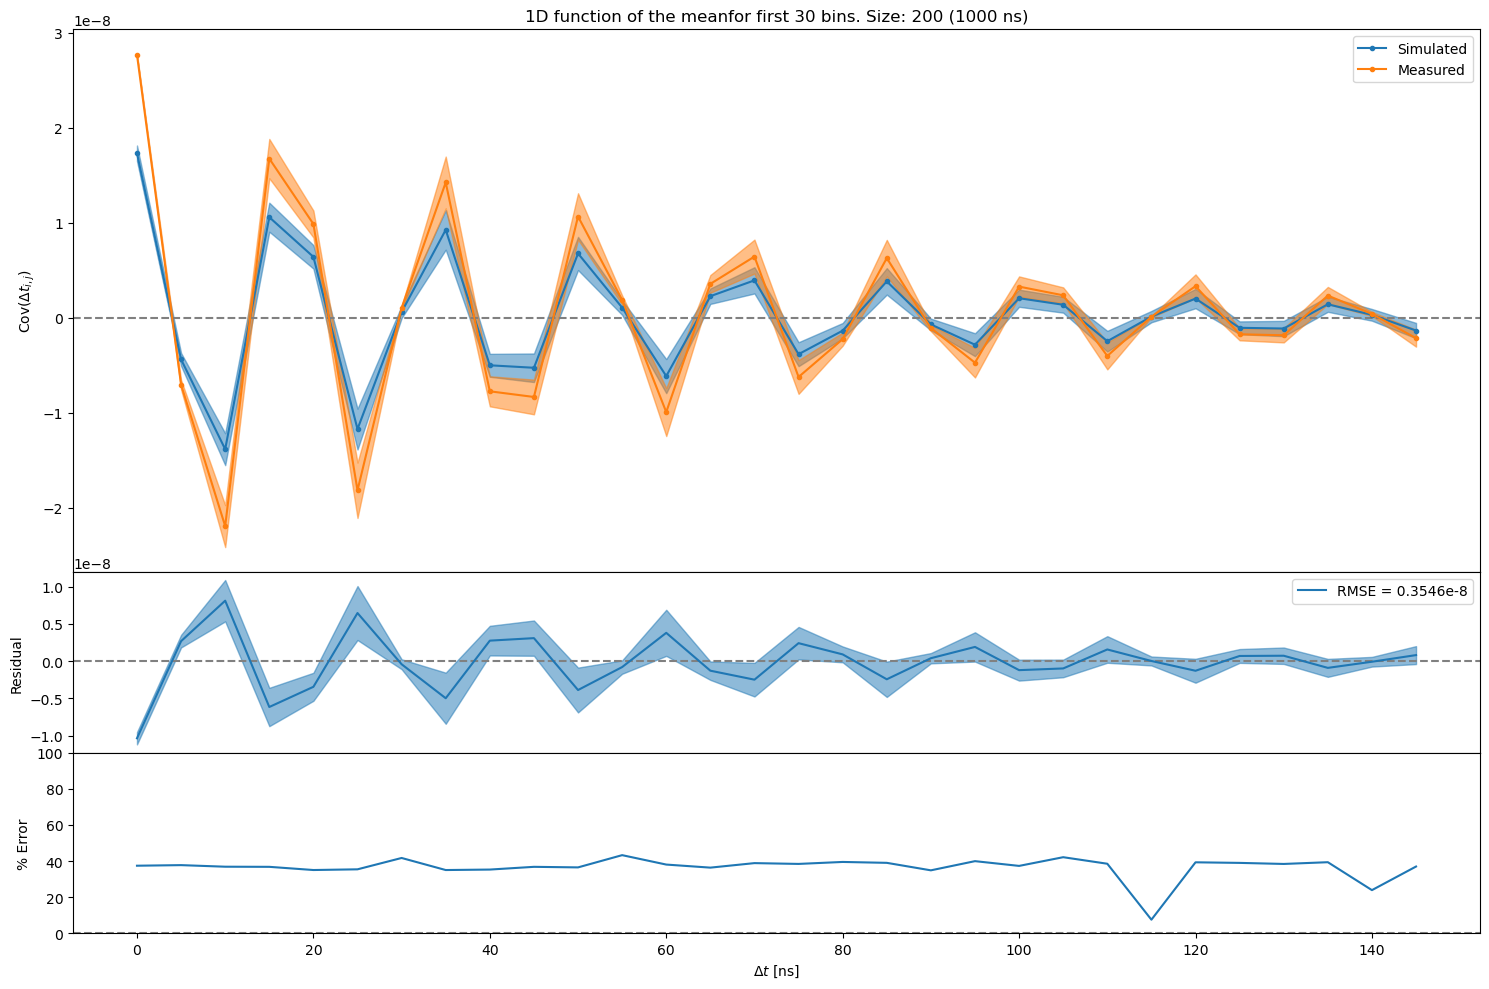

In [112]:
display_bin = 30
dur = single.shape[0]

s_single = transform_cov_for_1D(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas_data = transform_cov_for_1D(meas_data, display_bin)
mean_meas_data = np.mean(s_meas_data, axis=0)
stds_meas_data = np.std(s_meas_data, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas_data-stds_meas_data, mean_meas_data+stds_meas_data, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas_data, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas_data
diff_err = np.sqrt(stds_meas_data**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))*1e+8
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}e-8")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas_data *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 100)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()


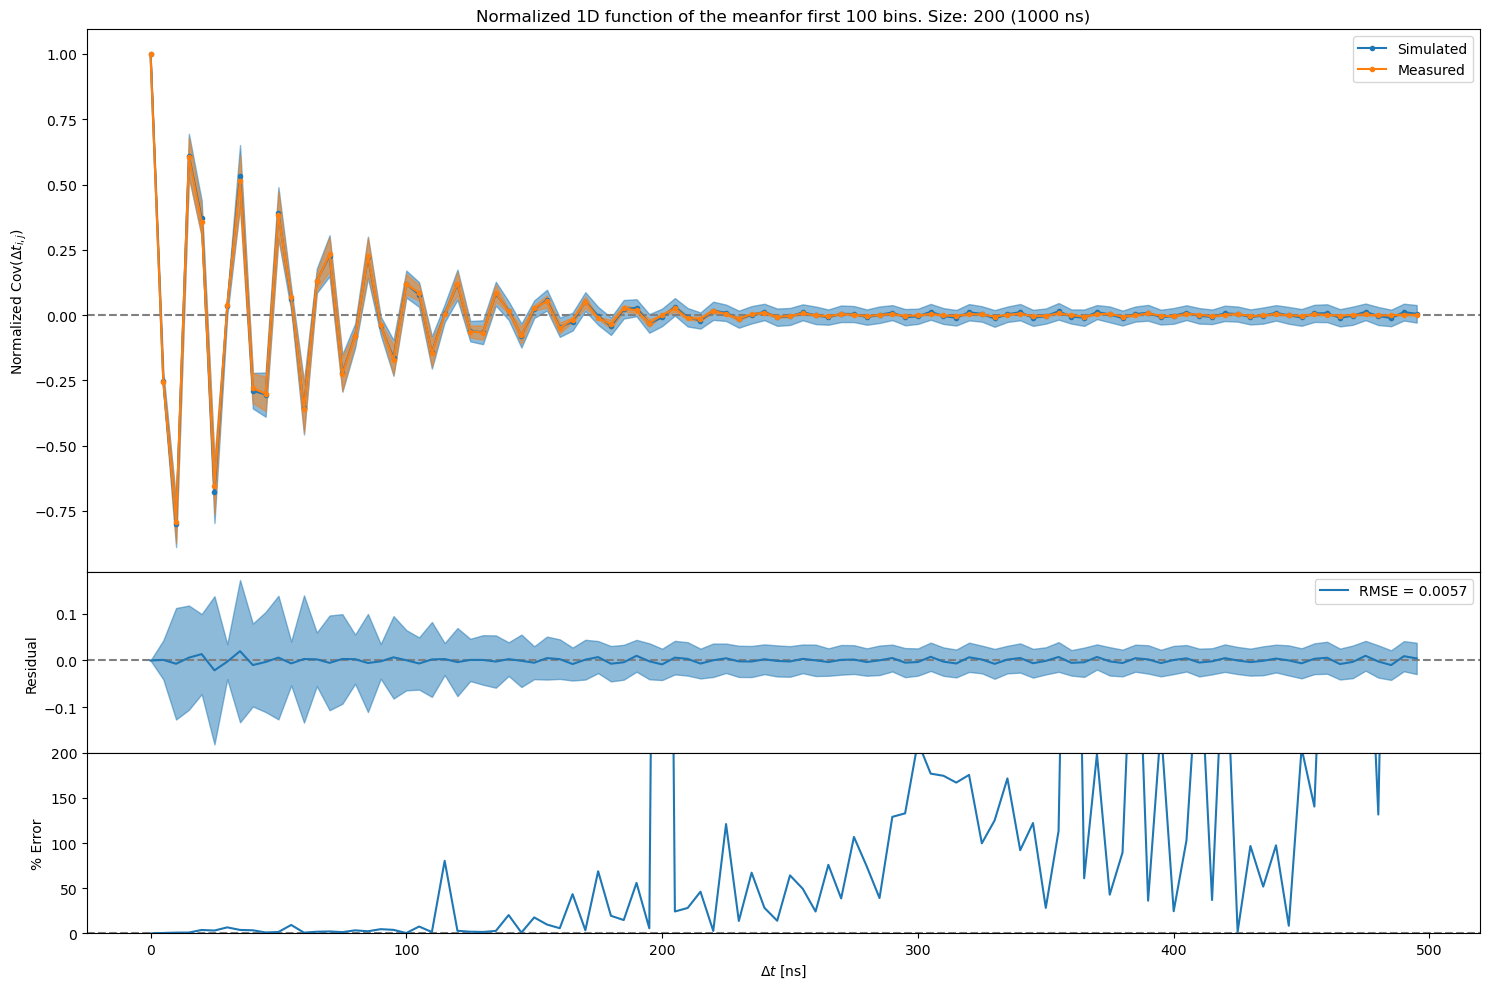

In [122]:
display_bin = 100
dur = single.shape[0]

s_single = transform_cov_for_1D_norm(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas_data = transform_cov_for_1D_norm(meas_data, display_bin)
mean_meas_data = np.mean(s_meas_data, axis=0)
stds_meas_data = np.std(s_meas_data, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas_data-stds_meas_data, mean_meas_data+stds_meas_data, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas_data, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"Normalized 1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas_data
diff_err = np.sqrt(stds_meas_data**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas_data *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 200)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()


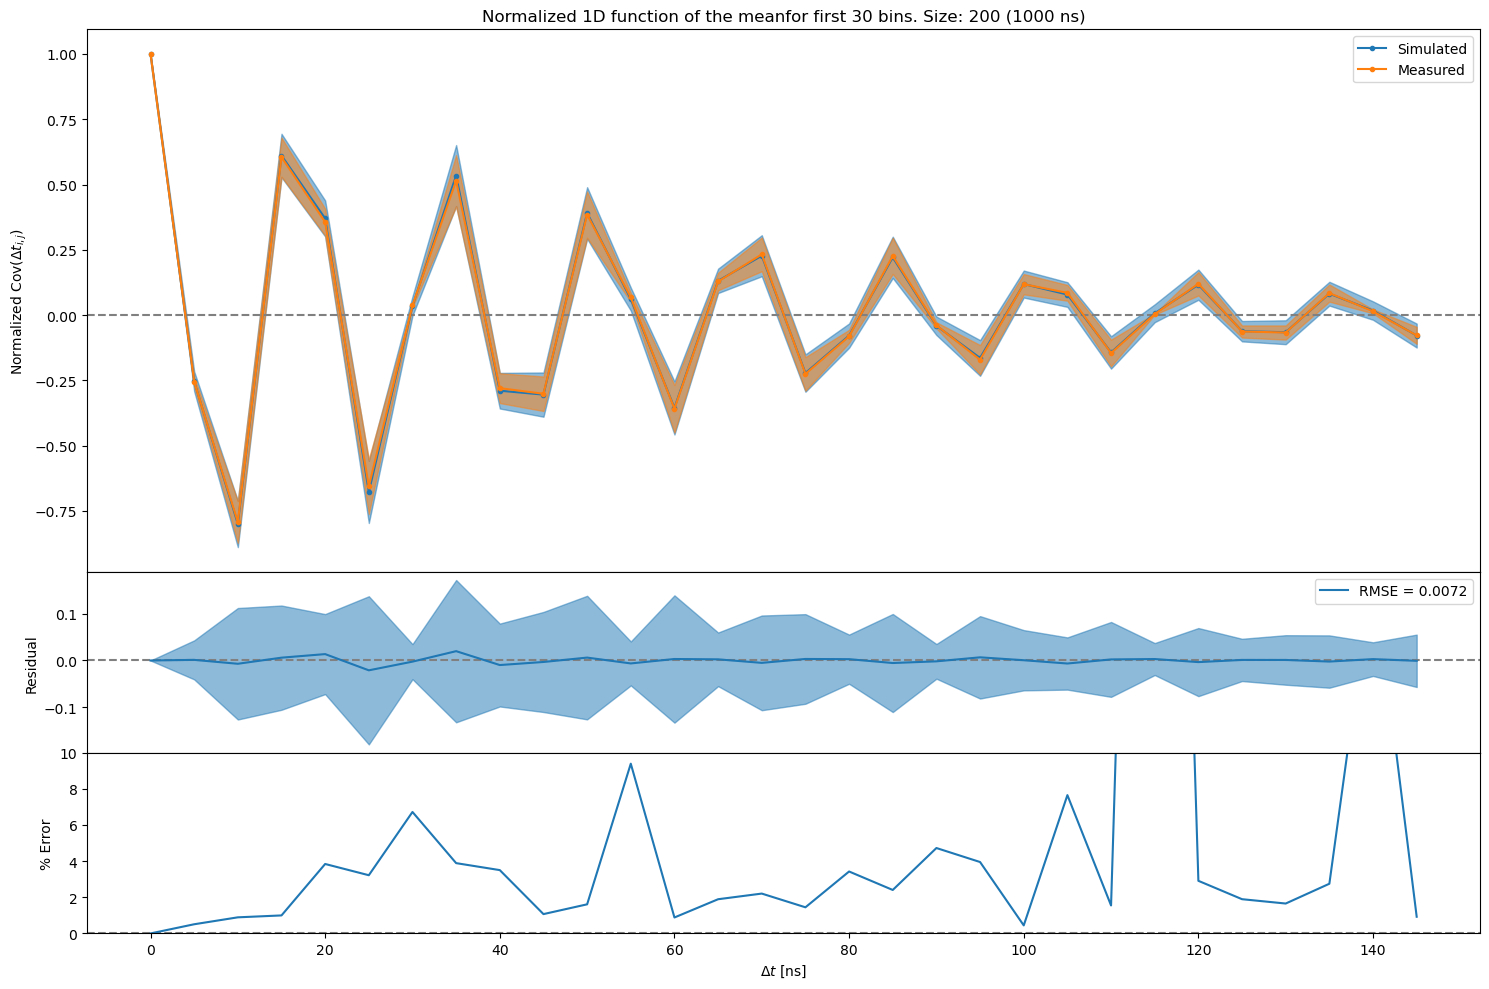

In [123]:
display_bin = 30
dur = single.shape[0]

s_single = transform_cov_for_1D_norm(single, display_bin)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_meas_data = transform_cov_for_1D_norm(meas_data, display_bin)
mean_meas_data = np.mean(s_meas_data, axis=0)
stds_meas_data = np.std(s_meas_data, axis=0)

small_x = np.arange(display_bin)*5

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1, 1], "hspace":0})

# vertical lines
# for j in range(2):
#     for i in range(ent):
#         axes[j].axvline(i*5, c="lightgray", linestyle="--")

# first plot
axes[0].axhline(y=0, c="gray", linestyle="--")

axes[0].fill_between(small_x, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
axes[0].fill_between(small_x, mean_meas_data-stds_meas_data, mean_meas_data+stds_meas_data, color="tab:orange", alpha=0.5)

axes[0].plot(small_x, mean_single, c="tab:blue", marker=".", label="Simulated")
axes[0].plot(small_x, mean_meas_data, c="tab:orange", marker=".", label="Measured")

axes[0].legend()
axes[0].set_ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

axes[0].set_title(f"Normalized 1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*5} ns)")

# residual plot
diff = mean_single - mean_meas_data
diff_err = np.sqrt(stds_meas_data**2 + stds_single**2)
rmse = np.sqrt(np.mean(diff**2))
axes[1].axhline(y=0, c="gray", linestyle="--")
axes[1].fill_between(small_x, diff+diff_err, diff-diff_err, color="tab:blue", alpha=0.5)
axes[1].plot(small_x, diff, c="tab:blue", label=f"RMSE = {rmse:.4f}")

axes[1].set_ylabel(r"Residual")
axes[1].legend()

# % error
per_err = np.abs(diff/mean_meas_data *100)

axes[2].axhline(y=0, c="gray", linestyle="--")
axes[2].plot(small_x, per_err)

axes[2].set_ylabel(r"% Error")
axes[2].set_ylim(0, 10)
plt.xlabel(r"$\Delta t$ [ns]")
plt.tight_layout()

plt.show()

# SKA vs LOFAR

In [81]:
def transform_cov_for_1D_norm(cov, display_bin):
    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    return small_cov/np.max(small_cov, axis=1)[:, None]

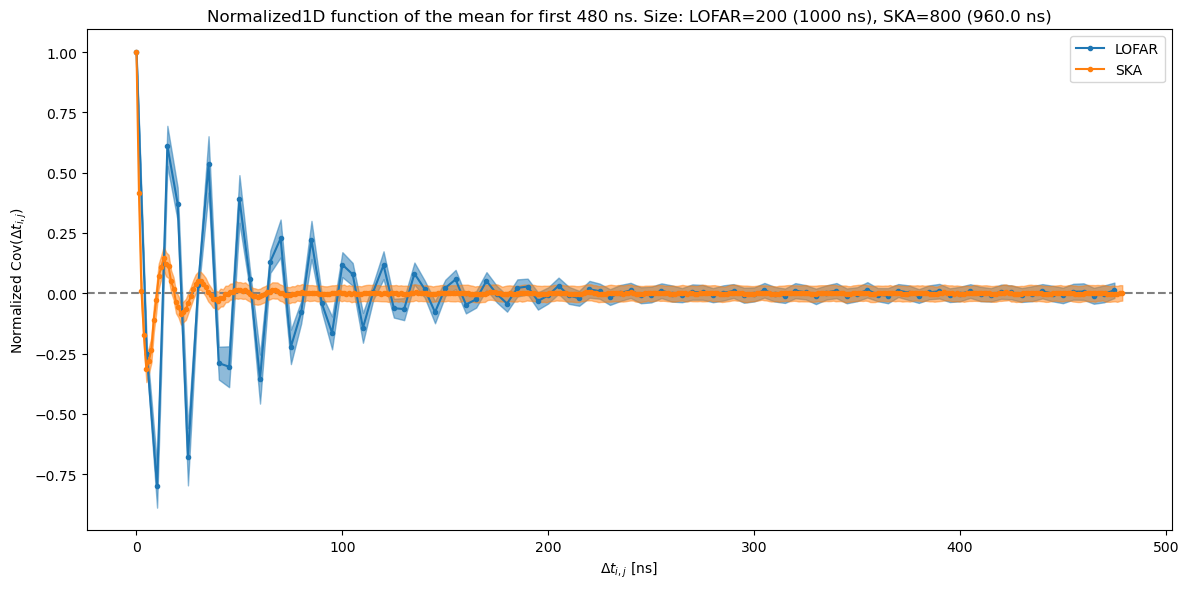

In [84]:
display_bin_LOFAR = 100
display_bin_LOFAR = (display_bin_LOFAR//6)*6
display_bin_SKA = int(display_bin_LOFAR*25/6)
dur_LOFAR = single.shape[0]
dur_SKA = c_200.shape[0]

s_single = transform_cov_for_1D_norm(single, display_bin_LOFAR)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_200 = transform_cov_for_1D_norm(c_200, display_bin_SKA)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

small_x_LOFAR = np.arange(display_bin_LOFAR)*5
small_x_SKA = np.arange(display_bin_SKA)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x_LOFAR, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
plt.fill_between(small_x_SKA, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)

plt.plot(small_x_LOFAR, mean_single, c="tab:blue", marker=".", label="LOFAR")
plt.plot(small_x_SKA, mean_200, c="tab:orange", marker=".", label="SKA")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized1D function of the mean for first {display_bin_LOFAR*5} ns. Size: LOFAR={dur_LOFAR} ({dur_LOFAR*5} ns), SKA={dur_SKA} ({dur_SKA*1.2} ns)")
plt.tight_layout()

plt.show()


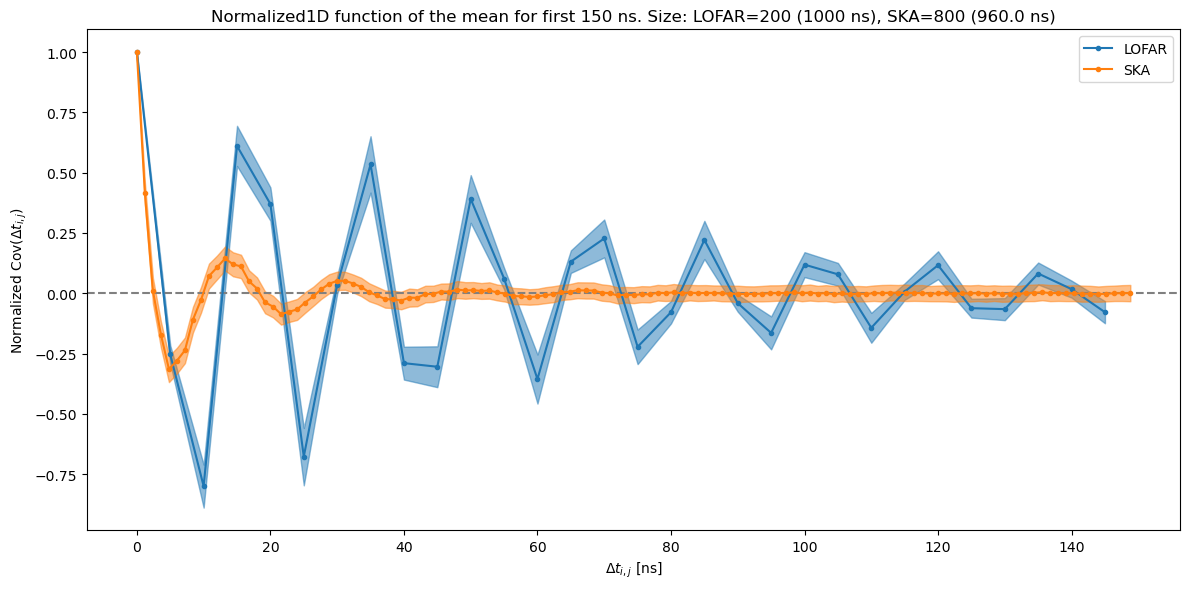

In [86]:
display_bin_LOFAR = 30
display_bin_LOFAR = (display_bin_LOFAR//6)*6
display_bin_SKA = int(display_bin_LOFAR*25/6)
dur_LOFAR = single.shape[0]
dur_SKA = c_200.shape[0]

s_single = transform_cov_for_1D_norm(single, display_bin_LOFAR)
mean_single = np.mean(s_single, axis=0)
stds_single = np.std(s_single, axis=0)

s_200 = transform_cov_for_1D_norm(c_200, display_bin_SKA)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

small_x_LOFAR = np.arange(display_bin_LOFAR)*5
small_x_SKA = np.arange(display_bin_SKA)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x_LOFAR, mean_single-stds_single, mean_single+stds_single, color="tab:blue", alpha=0.5)
plt.fill_between(small_x_SKA, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)

plt.plot(small_x_LOFAR, mean_single, c="tab:blue", marker=".", label="LOFAR")
plt.plot(small_x_SKA, mean_200, c="tab:orange", marker=".", label="SKA")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized1D function of the mean for first {display_bin_LOFAR*5} ns. Size: LOFAR={dur_LOFAR} ({dur_LOFAR*5} ns), SKA={dur_SKA} ({dur_SKA*1.2} ns)")
plt.tight_layout()

plt.show()
